# **INTEL IMAGE CLASSIFICATION USING CNN**
---
---
A Deep Learning Assignment

A Convolution Neural Network (CNN) was implemented to perform multi-class image classification of the image dataset, Intel Image Classification. Dataset consists of 25000 images of some natural scenes around the world which os grouped into six different categories:
- Buildings
- Forest
- Glacier
- Mountain
- Sea
- Street <br>

Objective of this project is to design, train, and evaluate a CNN model that can accurately classify images into these categories.

**Deep Learning Pipeline**<br>
---
Input Image (150,150,3)<br>
|<br>
Rescaling (Normalization (1/255))<br>
|<br>
Data Augmentation<br>
|<br>
Conv2D (32 filers, 3-3) + RELU<br>
|<br>
MaxPooling 2D(Downsampling)<br>
|<br>
Conv2D (64 filters, 3-3) + RELU<br>
|<br>
MaxPooling 2D<br>
|<br>
Conv2D (128 filters, 3-3) + RELU<br>
|<br>
MaxPooling 2D<br>
|<br>
Flatten<br>
|<br>
Dense layer (128 units) + RELU<br>
|<br>
Dropout (0.5)<br>
|<br>
Softmax<br>
|<br>
Predicted Class



#**1. Data Understanding and Preprocessing**



###1.1 Import Libraries
---



In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

from skimage.io import imread
from skimage.transform import resize

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout


In [2]:
# DEFINING DATASET PATH
#-----------------------------
train_dir = "/content/drive/MyDrive/intel_dataset/seg_train"
test_dir  = "/content/drive/MyDrive/intel_dataset/seg_test"
pred_dir  = "/content/drive/MyDrive/intel_dataset/seg_pred"

### 1.2 Load Dataset

---


Dataset is loaded using Tensorflow's **image_dataset_from_directory** function which automatically
- read folders as labels
- resize images
- batches data
- avoid loading everything into RAM

In [3]:
IMG_SIZE = (150,150)
BATCH_SIZE = 32

In [4]:
# Load Training Dataset with Validation split
#---------------------------------------------------

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# SAVE CLASS NAMES HERE
class_names = train_ds.class_names
print('\nclass names:',class_names)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.

class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [22]:
# Load Test Data
#---------------------

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 3000 files belonging to 6 classes.


###1.4 Data Augmentation

---


To improve generalization and reduce overfitting augmentation techniques are applied to the training dataset. Techniques includes:
- Random horizontal flipping
- Random rotation
- Random zoom
- Random translation
- Random contrast adjustment<br>

Data augmentation increases dataset diversity without increasing datasets size.

In [6]:
# Speed optimization
#---------------------
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1,0.1),
    layers.RandomContrast(0.1)
])



#**2. Build CNN Model**


Model architecture includes:
- Rescaling layer (Normalization)
- 3 Convolution layers
- MaxPooling layers
- Flatten layer
- Dense layer
- Dropout for regularization
- Softmax output layer (6 classes)

> Add blockquote




###2.1 Build CNN Architecture
---

In [8]:
model = models.Sequential([

    # augmentation + normaization
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(150,150,3)),

    # Conv Block 1
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Conv Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Conv Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    # Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(6, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 2.2 Compile the Model
---
Loss function : Sparse Categorical Cross Entropy (Multi class classification)

In [9]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

### 2.3 Define Callbacks
---
- EarlyStopping prevvents overfitting
- ModelCheckpoint saves the best model

In [10]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True
)

### 2.4 Train the Model
---
Model is trained using training data and validated using validation data

In [12]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20,
    callbacks = [early_stop, checkpoint]
)


Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4413 - loss: 1.3768

351/351 ━━━━━━━━━━━━━━━━━━━━ 1983s 2s/step - accuracy: 0.4415 - loss: 1.3763 - val_accuracy: 0.5552 - val_loss: 1.2246
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6208 - loss: 0.9979

351/351 ━━━━━━━━━━━━━━━━━━━━ 562s 2s/step - accuracy: 0.6208 - loss: 0.9979 - val_accuracy: 0.6140 - val_loss: 1.0214
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6591 - loss: 0.9259

351/351 ━━━━━━━━━━━━━━━━━━━━ 569s 2s/step - accuracy: 0.6591 - loss: 0.9259 - val_accuracy: 0.7363 - val_loss: 0.7096
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 552s 2s/step - accuracy: 0.6898 - loss: 0.8407 - val_accuracy: 0.7373 - val_loss: 0.7321
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 553s 2s/step - accuracy: 0.7075 - loss: 0.8025 - val_accuracy: 0.7320 - val_loss: 0.7762
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7310 - loss: 0.7636

351/351 ━━━━━━━━━━━━━━━━━━━━ 554s 2s/step - accuracy: 0.7310 - loss: 0.7636 - val_accuracy: 0.7766 - val_loss: 0.6381
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 561s 2s/step - accuracy: 0.7437 - loss: 0.7289 - val_accuracy: 0.7234 - val_loss: 0.7198
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7562 - loss: 0.6907

351/351 ━━━━━━━━━━━━━━━━━━━━ 550s 2s/step - accuracy: 0.7562 - loss: 0.6907 - val_accuracy: 0.7837 - val_loss: 0.5915
Epoch 9/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7655 - loss: 0.6672

351/351 ━━━━━━━━━━━━━━━━━━━━ 565s 2s/step - accuracy: 0.7654 - loss: 0.6673 - val_accuracy: 0.7944 - val_loss: 0.5863
Epoch 10/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7632 - loss: 0.6696

351/351 ━━━━━━━━━━━━━━━━━━━━ 555s 2s/step - accuracy: 0.7632 - loss: 0.6695 - val_accuracy: 0.8011 - val_loss: 0.5558
Epoch 11/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7731 - loss: 0.6413

351/351 ━━━━━━━━━━━━━━━━━━━━ 573s 2s/step - accuracy: 0.7731 - loss: 0.6413 - val_accuracy: 0.8143 - val_loss: 0.5286
Epoch 12/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 566s 2s/step - accuracy: 0.7862 - loss: 0.6169 - val_accuracy: 0.8108 - val_loss: 0.5410
Epoch 13/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 560s 2s/step - accuracy: 0.7750 - loss: 0.6267 - val_accuracy: 0.8040 - val_loss: 0.5428
Epoch 14/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 559s 2s/step - accuracy: 0.7865 - loss: 0.6050 - val_accuracy: 0.8043 - val_loss: 0.5490


###2.5 Plot Training & Validation Curves
---
These plots help detect overfitting, Underfitting or Convergence behaviour

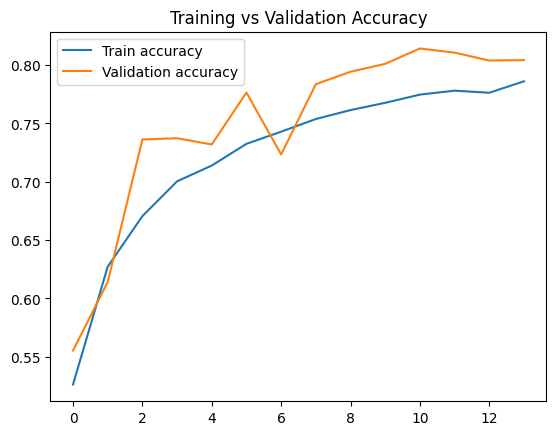

In [13]:
# Accuracy Curve
#---------------------
plt.plot(history.history['accuracy'],label='Train accuracy')
plt.plot(history.history['val_accuracy'],label='Validation accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()



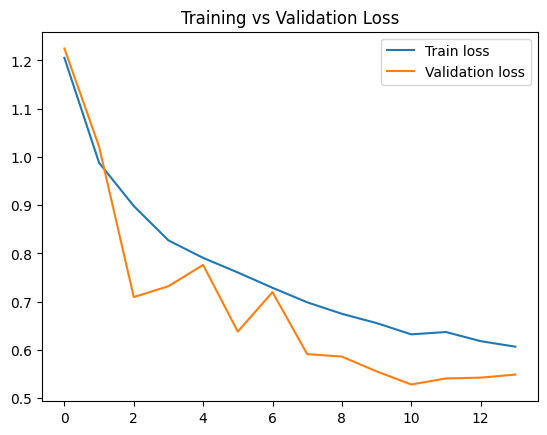

In [14]:
# Loss Curve
#-------------------
plt.plot(history.history['loss'],label='Train loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


#**3. Model Evaluation & Interpretation**

Evaluation on test data gives final unbiased performance of the model

###3.1 Evaluate Test data
---
Provides final unbiased performance of the model

In [15]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'Test Accuracy: {test_acc}')

94/94 ━━━━━━━━━━━━━━━━━━━━ 373s 4s/step - accuracy: 0.8670 - loss: 0.4137
Test Accuracy: 0.8076666593551636


###3.2 Classification report
---
Provides precision, recall and f1 score for each class


In [29]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred = np.argmax(model.predict(test_ds), axis=1)

print(classification_report(y_true, y_pred, target_names=test_ds.class_names))


94/94 ━━━━━━━━━━━━━━━━━━━━ 44s 462ms/step
              precision    recall  f1-score   support

   buildings       0.66      0.92      0.76       437
      forest       0.94      0.97      0.95       474
     glacier       0.78      0.74      0.76       553
    mountain       0.82      0.71      0.76       525
         sea       0.81      0.80      0.81       510
      street       0.88      0.75      0.81       501

    accuracy                           0.81      3000
   macro avg       0.82      0.81      0.81      3000
weighted avg       0.82      0.81      0.81      3000



###3.3 Confusion Matrix
---
Shows correct vs incorrect classifications

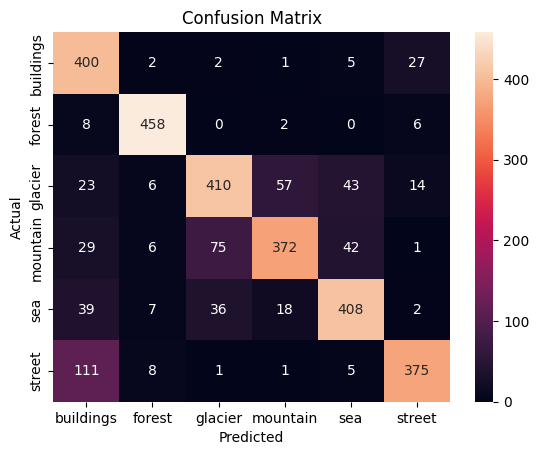

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


###3.4 Visualize 10 Random Test Predictions
---
Displays 10 test images with predicyed and actual labels

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step


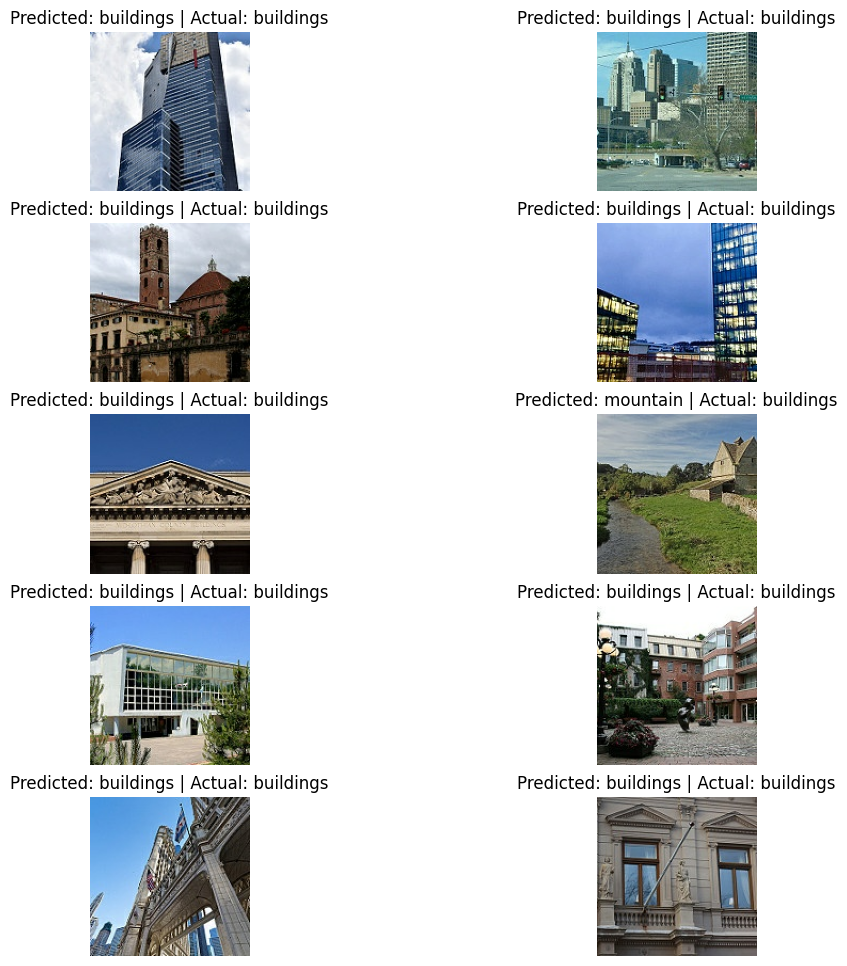

In [28]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(iter(test_ds))
preds = model.predict(images)

plt.figure(figsize=(12,12))

for i in range(10):
    plt.subplot(5,2,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))

    pred_labels = class_names[np.argmax(preds[i])]
    true_labels = class_names[labels[i]]

    plt.title(f"Predicted: {pred_labels} | Actual: {true_labels}")
    plt.axis('off')

plt.show()


#**4. Summary & Conclusions**

Developed a CNN model to classify images into 6 scene categories: buildings, forest, glacier, mountain, sea, and street.
- Loaded images from Google Drive using image_dataset_from_directory with resizing and normalization preprocessing

- Model trained and evaluated using accuracy, classification report, and confusion matrix

- Achieved ~80.7% test accuracy, showing good learning capability



Key Observations:
- Best performance: forest (distinct texture patterns)

- Major confusion: buildings ↔ street (similar man-made structures)

- Secondary confusion: glacier ↔ mountain (similar terrain appearance)

- CNN mainly learns texture features rather than semantic context

Model performs well for a basic CNN architecture. Accuracy can be improved using data augmentation, deeper models, or transfer learning.